# GRB 240629A: A Joint BurstCube/GBM Worked Example

This notebook is a complete worked analysis of one real burst, from trigger
discovery through a spectral fit, using nothing but the public archive and
this plugin. Unlike notebooks 1-3, which introduce each data product on its
own, this one chains them together the way a real analysis would:

1. Get the trigger time and duration from Fermi GBM's own detection (GBM
   triggered; BurstCube, with no onboard trigger, did not).
2. Download the corresponding BurstCube CBD data.
3. Plot the light curve: all 4 BurstCube detectors individually and summed,
   overlaid with GBM's own light curve for the two NaI detectors that
   triggered.
4. Confirm which of BurstCube's 3 reconstructed attitude epochs covers this
   trigger, and use it to get the appropriate detector response.
5. Fit the background, excluding GBM's T90 plus a 10 s buffer on each side.
6. Fold the on-source counts, background, and response together to fit a
   power-law spectrum.

GBM's own data comes from `astro-gdt-fermi` (`gdt.missions.fermi.gbm`), the
sibling plugin this package is modelled on -- installed here only for this
notebook, not a runtime dependency of `astro-gdt-burstcube` itself. Per
notebook 3, real BurstCube attitude exists for only 3 brief epochs across
the whole mission; this burst is a worked example specifically *because* one
of them happens to cover it, which section 4 confirms rather than assumes.

This notebook does double duty. A burst detected by another spacecraft has
an arrival time known independently of BurstCube's own clock, which makes it
the one thing that can test that clock from outside. That test is what
established the archive's stated MET epoch to be wrong by 37 s (README
Caveats); everything below uses the corrected epoch, and Step 3 shows what
the same data looks like without it.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time as AstroTime
from astropy.coordinates import SkyCoord

from gdt.core import data_path
from gdt.core.binning.unbinned import bin_by_edges
from gdt.core.background.fitter import BackgroundFitter
from gdt.core.background.binned import Polynomial
from gdt.core.spectra.fitting import SpectralFitterPgstat
from gdt.core.spectra.functions import PowerLaw

from gdt.missions.burstcube.cbd import BurstCubeCBD
from gdt.missions.burstcube.time import Time as BCTime
from gdt.missions.burstcube.finders import BurstCubeObsFinder, BurstCubeTrendFinder
from gdt.missions.burstcube.attitude import BurstCubeAttitude
from gdt.missions.burstcube.response import BurstCubeResponseGrid

from gdt.missions.fermi.gbm.catalogs import BurstCatalog, TriggerCatalog
from gdt.missions.fermi.gbm.finders import TriggerFinder
from gdt.missions.fermi.gbm.tte import GbmTte

# Every archive file's own header states a MET epoch 37 s later than the
# truth, so each open() warns (README Caveats, and Step 2 below). The
# corrected TAI epoch is applied either way; silenced for readable output.
warnings.filterwarnings('ignore', message=".*state an epoch of.*")

%matplotlib inline

## Step 1: The trigger, from GBM's own catalogs

GBM's Burst Catalog (`fermigbrst`) carries the standard analysis for every
triggered GRB -- trigger time, T90, T90 start, and the two power-law fits
(peak-flux and fluence-averaged) this notebook will need later for
comparison. Its Trigger Catalog (`fermigtrig`) instead carries the flight
trigger itself, including which detectors actually fired -- that is a
different question from which detectors the ground analysis judged worth
using (`BCAT_DETECTOR_MASK`/`SCAT_DETECTOR_MASK` in the burst catalog), so
this notebook queries both.

Both catalogs key on a burst/trigger name; `GRB 240629A` is `GRB240629704`
(GBM's own name has the trigger time baked in as `YYMMDDfff`) and its
trigger number is `240629704`. Rather than take that number for granted,
this cell looks it up: the burst catalog's `NAME` column is what a science
archive would actually be searched by.

In [2]:
burst_cat = BurstCatalog()
table = burst_cat.get_table(columns=(
    'name', 'trigger_time', 't90', 't90_error', 't90_start', 't50',
    'ra', 'dec', 'error_radius',
    'flnc_plaw_index', 'flnc_plaw_ergflux', 'flnc_plaw_ergflux_error',
    'pflx_plaw_index', 'pflx_plaw_ergflux',
))
row = table[np.char.strip(table['NAME']) == 'GRB240629704'][0]

trigger_time = AstroTime(row['TRIGGER_TIME'], format='mjd', scale='utc')
t90, t90_error, t90_start, t50 = (row['T90'], row['T90_ERROR'],
                                  row['T90_START'], row['T50'])
ra, dec, error_radius = row['RA'], row['DEC'], row['ERROR_RADIUS']

print(f"GRB240629704 trigger time: {trigger_time.isot} UTC (MJD {row['TRIGGER_TIME']})")
print(f'T90 = {t90} +/- {t90_error} s, starting {t90_start} s after trigger; T50 = {t50} s')
print(f'RA = {ra}, Dec = {dec}, error radius = {error_radius} deg')

Sending request and awaiting response from HEASARC...


Finished in 64 s
GRB240629704 trigger time: 2024-06-29T16:53:52.729 UTC (MJD 60490.704082514)
T90 = 7.165 +/- 0.722 s, starting 0.003 s after trigger; T50 = 2.56 s
RA = 314.52, Dec = -38.83, error radius = 2.23 deg


In [3]:
trigger_cat = TriggerCatalog()
trig_table = trigger_cat.get_table(columns=('trigger_name', 'detector_mask'))
trig_row = trig_table[np.char.strip(trig_table['TRIGGER_NAME']) == 'bn240629704'][0]

from gdt.missions.fermi.gbm.detectors import GbmDetectors
mask = trig_row['DETECTOR_MASK']
triggered = [det.name for det in GbmDetectors if mask[det.value[1]] == '1']
print(f'flight trigger detector mask: {mask}')
print(f'detectors that triggered: {triggered}')

Sending request and awaiting response from HEASARC...


Finished in 6 s
flight trigger detector mask: 00000000100100
detectors that triggered: ['n8', 'nb']


The flight trigger fired on two NaI detectors, `n8` and `nb` (GBM's
14-detector naming runs `n0`-`n9`, then `na`, `nb` for the last two NaIs,
then `b0`, `b1` for the two BGOs -- `nb` is `NAI_11`, commonly written
"n11"). Both are used below, plotted separately, since a single "the
detector that triggered" does not exist for this burst.

## Step 2: Download the BurstCube CBD data

Same pattern as notebook 1: `BurstCubeObsFinder` downloads directly, since
the archive layout is deterministic. The observation day is the trigger
date, `240629`; all 4 detectors, cleaned (`_cl`) variant only, per this
project's convention of using `_cl` everywhere except where the `_uf`/`_cl`
difference is itself the subject.

In [4]:
OBS_ID = '240629'
DETECTORS = ['CS0', 'CS1', 'CS2', 'CS3']

download_dir = Path(data_path) / 'burstcube' / OBS_ID
download_dir.mkdir(parents=True, exist_ok=True)

finder = BurstCubeObsFinder()
finder.cd(OBS_ID)
cbd_paths = finder.get_cbd(download_dir, detectors=DETECTORS, variant='cl', verbose=False)

cbds = {det: BurstCubeCBD.open(path) for det, path in zip(DETECTORS, cbd_paths)}
for det, cbd in cbds.items():
    print(f'{det}: {cbd.data.size[0]} bins, {cbd.time_range[0]:.3f} - {cbd.time_range[1]:.3f} (MET)')

CS0: 61804 bins, 110218562.420 - 110246399.796 (MET)
CS1: 61804 bins, 110218562.420 - 110246399.796 (MET)
CS2: 61804 bins, 110218562.420 - 110246399.796 (MET)
CS3: 61804 bins, 110218562.420 - 110246399.796 (MET)


BurstCube's mission clock (MET) is not Fermi's: both count seconds from
their own epoch. Converting the GBM trigger time through
`astropy.time.Time` and this plugin's own `gdt.missions.burstcube.time.Time`
gives the same instant on BurstCube's clock, which every BurstCube time
below is expressed relative to.

That conversion uses the **corrected** MET epoch, 2021-01-01 00:00:00 TAI,
not the 2021-01-01 00:00:00 UTC the archive's own `MJDREFI`/`MJDREFF`/
`TIMESYS` state -- they are wrong by 37 s (README Caveats). Opening any
archive file warns about it; the warning is silenced in the imports cell
above. This notebook is where that correction is put to the test: a burst
whose arrival time is known independently, from another spacecraft.

In [5]:
bc_trigtime = BCTime(trigger_time).burstcube
print(f'GBM trigger time on the BurstCube clock: MET {bc_trigtime:.3f}')

GBM trigger time on the BurstCube clock: MET 110220869.729


## Step 3: Light curve

BurstCube's 4 CBD files share identical 0.256 s bin edges (checked below),
so the 4 individual light curves and their sum can be built directly from
the counts arrays. GBM's own CTIME light curve, by contrast, uses adaptive
time binning (as short as ~2 ms near a trigger) rather than a fixed
cadence, so it cannot be overlaid on BurstCube's bins directly. GBM TTE --
unbinned, like BurstCube's own TTE -- does not have this problem: binning
it onto BurstCube's own bin edges with `bin_by_edges` is the same pattern
notebook 1 uses to compare BurstCube TTE against BurstCube CBD.

In [6]:
edges_match = all(
    np.array_equal(cbds['CS0'].data.tstart, cbds[det].data.tstart) and
    np.array_equal(cbds['CS0'].data.tstop, cbds[det].data.tstop)
    for det in DETECTORS[1:]
)
print(f'all 4 detectors share identical bin edges: {edges_match}')

all 4 detectors share identical bin edges: True


In [7]:
gbm_dir = Path(data_path) / 'fermi_gbm' / 'bn240629704'
gbm_dir.mkdir(parents=True, exist_ok=True)

gbm_trigger_finder = TriggerFinder('240629704')
tte_paths = gbm_trigger_finder.get_tte(gbm_dir, dets=['n8', 'nb'], verbose=False)
gbm_tte = {det: GbmTte.open(path) for det, path in zip(['n8', 'nb'], tte_paths)}
for det, tte in gbm_tte.items():
    print(f'{det}: {tte.data.size} events, trigtime MET {tte.trigtime:.3f} (Fermi clock)')

n8: 691710 events, trigtime MET 741372837.729 (Fermi clock)
nb: 760416 events, trigtime MET 741372837.729 (Fermi clock)


In [8]:
PLOT_HALF_WIDTH = 60.0  # seconds around the trigger

window = (bc_trigtime - PLOT_HALF_WIDTH, bc_trigtime + PLOT_HALF_WIDTH)
mask = (cbds['CS0'].data.tstart > window[0]) & (cbds['CS0'].data.tstop < window[1])
bin_edges_rel = np.unique(np.concatenate([
    cbds['CS0'].data.tstart[mask] - bc_trigtime,
    cbds['CS0'].data.tstop[mask] - bc_trigtime,
]))

bc_counts = {det: cbds[det].data.counts[mask].sum(axis=1) for det in DETECTORS}
bc_exposure = cbds['CS0'].data.exposure[mask]
bc_rates = {det: counts / bc_exposure for det, counts in bc_counts.items()}
bc_sum_rate = sum(bc_counts.values()) / bc_exposure

# GBM TTE's own time is already relative to its own (Fermi) trigger time,
# which is the same instant as bc_trigtime, so the edges line up directly.
gbm_binned = {
    det: tte.data.bin(bin_by_edges, bin_edges_rel,
                      tstart=bin_edges_rel[0], tstop=bin_edges_rel[-1])
    for det, tte in gbm_tte.items()
}
gbm_rates = {det: b.counts.sum(axis=1) / b.exposure for det, b in gbm_binned.items()}

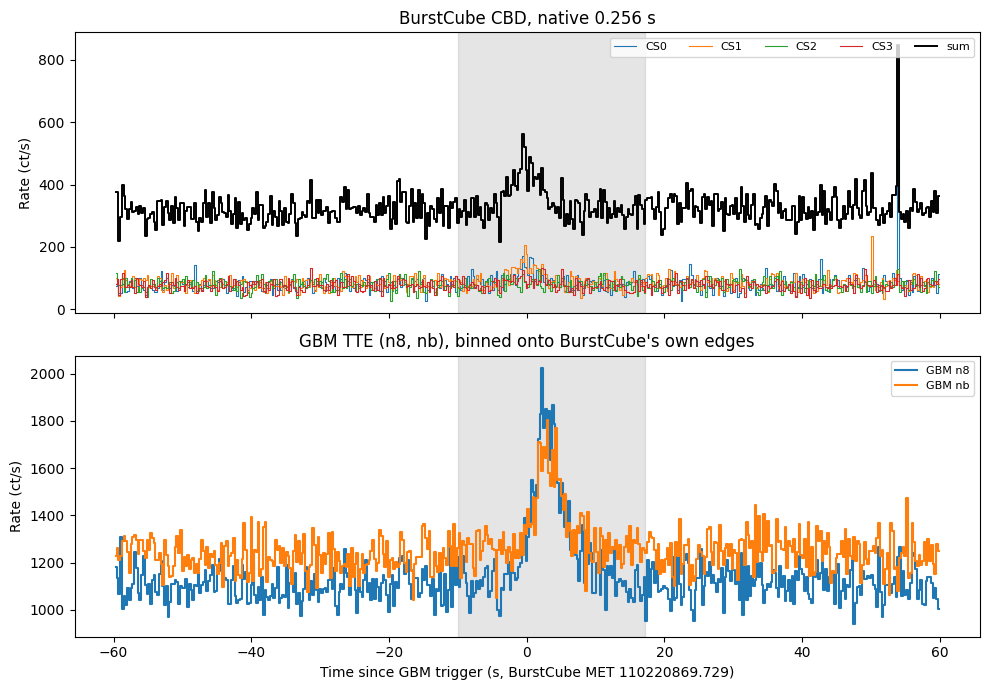

In [9]:
on_start = t90_start - 10.0
on_stop = t90_start + t90 + 10.0

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

centroids = 0.5 * (bin_edges_rel[:-1] + bin_edges_rel[1:])
for det in DETECTORS:
    axes[0].step(centroids, bc_rates[det], where='mid', lw=0.8, label=det)
axes[0].step(centroids, bc_sum_rate, where='mid', lw=1.4, color='k', label='sum')
axes[0].set_ylabel('Rate (ct/s)')
axes[0].set_title('BurstCube CBD, native 0.256 s')
axes[0].legend(ncol=5, fontsize=8, loc='upper right')

for det, color in zip(['n8', 'nb'], ['C0', 'C1']):
    axes[1].step(centroids, gbm_rates[det], where='mid', label=f'GBM {det}', color=color)
axes[1].set_ylabel('Rate (ct/s)')
axes[1].set_xlabel(f'Time since GBM trigger (s, BurstCube MET {bc_trigtime:.3f})')
axes[1].set_title('GBM TTE (n8, nb), binned onto BurstCube\'s own edges')
axes[1].legend(fontsize=8, loc='upper right')

for ax in axes:
    ax.axvspan(on_start, on_stop, color='gray', alpha=0.2,
              label='T90 + 10 s buffer' if ax is axes[1] else None)

fig.tight_layout()
plt.show()

Both instruments show the burst in the same place. GBM detects it strongly
in `n8` and `nb`; BurstCube's summed curve carries a clear excess over the
same few seconds, weaker and noisier as expected from a detector with a
fraction of GBM's area viewing the burst from past its own horizon. Steps
5-6 put a number on it rather than reading it off this plot by eye.

That the two line up at all depends on the corrected MET epoch. Converted
with the epoch the archive's headers state, BurstCube's excess would sit
34 s to the right of GBM's and this panel would look like a non-detection
with an unexplained bump after it.

## Step 4: Confirm the attitude epoch, and get the response

Per notebook 3 and archive caveat #1, real reconstructed attitude exists
for only 3 brief epochs across the whole BurstCube mission. This burst is a
useful worked example only if one of them actually covers it -- so confirm
that, rather than assume it.

In [10]:
trend_finder = BurstCubeTrendFinder()
att_path = trend_finder.get_attitude(Path(data_path) / 'burstcube' / 'trend')
att = BurstCubeAttitude.open(att_path)

epoch_dt = np.array([att.time[i].burstcube - bc_trigtime for i in range(att.num_rows)])
best_epoch = int(np.argmin(np.abs(epoch_dt)))
for i in range(att.num_rows):
    ra_i, dec_i, roll_i = att.pointing[i]
    print(f'epoch {i}: MET={att.time[i].burstcube:.3f}  Delta_t={epoch_dt[i]:+.3f} s  '
         f'RA={ra_i:.3f} Dec={dec_i:.3f} roll={roll_i:.3f}')
print(f'\nclosest epoch to the trigger: {best_epoch}, {abs(epoch_dt[best_epoch]):.1f} s away')

Output()

epoch 0: MET=110220808.000  Delta_t=-61.729 s  RA=48.723 Dec=10.862 roll=333.950
epoch 1: MET=111198020.000  Delta_t=+977150.271 s  RA=350.986 Dec=49.458 roll=297.417
epoch 2: MET=111465000.000  Delta_t=+1244130.271 s  RA=182.682 Dec=-46.037 roll=69.148

closest epoch to the trigger: 0, 61.7 s away


Epoch 0 is about a minute from the trigger -- by far the closest of the 3,
and well inside its own ~10-12 deg reconstruction uncertainty over that
timescale. This is the attitude used below; the other 2 epochs are hours to
weeks away and irrelevant to this burst.

With that quaternion, the GRB's sky position transforms into BurstCube's
spacecraft frame, and `BurstCubeResponseGrid` interpolates a DRM there for
each detector -- the response grid is in `(az, zen)`, while the frame's own
representation is `(az, el)` (`zen = 90 - el`, per notebook 2).

In [11]:
epoch_frame = att.frame(best_epoch)
grb_coord = SkyCoord(ra=ra, dec=dec, unit='deg')
sc = grb_coord.transform_to(epoch_frame)
az = float(np.atleast_1d(sc.az.deg)[0])
el = float(np.atleast_1d(sc.el.deg)[0])
zen = 90.0 - el
print(f'GRB position in the spacecraft frame: az={az:.3f}, zen={zen:.3f} deg '
     f'(el={el:.3f}, i.e. just past the local horizon)')

GRB position in the spacecraft frame: az=243.959, zen=100.034 deg (el=-10.034, i.e. just past the local horizon)


In [12]:
grid = BurstCubeResponseGrid()
rsps = {}
for det in DETECTORS:
    drm = grid.get_drm(det, az=az, zen=zen, interp=True)
    rsps[det] = drm.to_cbd()
    # per gdt-core issue #3: channel_effective_area() is an unweighted
    # column sum, not in cm^2 -- photon_effective_area() (vs. incident
    # photon energy, not recorded channel) is the one that is.
    eff_area = rsps[det].drm.photon_effective_area()
    peak_idx = np.argmax(eff_area.counts)
    peak_energy = eff_area.centroids[peak_idx]
    print(f'{det}: peak effective area {eff_area.counts[peak_idx]:.2f} cm^2 at {peak_energy:.0f} keV')

CS0: peak effective area 18.42 cm^2 at 303 keV
CS1: peak effective area 45.04 cm^2 at 157 keV


CS2: peak effective area 25.34 cm^2 at 178 keV


CS3: peak effective area 18.02 cm^2 at 342 keV


Real, non-degenerate effective area at all 4 detectors, but well below each
detector's own on-axis peak (~60-70 cm^2, at its own boresight) -- `zen`
just past 90 deg means the GRB is slightly past BurstCube's local horizon
for this attitude, so this is reduced, off-axis sensitivity, not the best
case.

## Step 5: Background fit

Per this notebook's brief, the ON (exclusion) region is GBM's own T90 plus
a 10 s buffer on each side: `[T90_start - 10, T90_start + T90 + 10]`. Wide
background windows bracket it on both sides.

One bin inside the post-burst window has to come out first. At t0+54 s a
single 0.256 s bin in `CS0` alone reads 515.6 ct/s against its own ~78 ct/s
median, while the other three detectors sit flat through the same bin and
`CS0`'s immediate neighbours are normal. A real sky signal illuminates more
than one detector, and no astrophysical burst lasts exactly one bin and
stops. This is a **phosphorescence event**: a cosmic-ray ion or a heavy
particle deposits a large amount of energy in one scintillator crystal, and
the crystal re-emits that energy as a burst of delayed optical photons,
which the readout counts as a spray of spurious events in that detector
only. Left in the background windows it would drag the fitted `CS0`
baseline up across the whole day.

Rather than hardcode its time, the cell below finds it: a bin where one
detector exceeds its own median by a large factor while every other
detector stays near its own. The background windows are then split around
whatever it finds.

In [13]:
ON_START, ON_STOP = t90_start - 10.0, t90_start + t90 + 10.0
BKG_WINDOWS = [(-115.0, -20.0), (20.0, 115.0)]

ref = cbds['CS0'].data
rel_start, rel_stop = ref.tstart - bc_trigtime, ref.tstop - bc_trigtime
in_bkg = np.zeros(rel_start.size, dtype=bool)
for lo, hi in BKG_WINDOWS:
    in_bkg |= (rel_start >= lo) & (rel_stop <= hi)

rates = np.vstack([cbds[det].data.counts.sum(axis=1) / cbds[det].data.exposure
                   for det in DETECTORS])
ratio = rates / np.median(rates[:, in_bkg], axis=1)[:, None]
loudest, runner_up = ratio.max(axis=0), np.sort(ratio, axis=0)[-2]

# one detector far above its own median, all others near theirs
flagged = np.flatnonzero(in_bkg & (loudest > 4.0) & (runner_up < 2.0))
print(f'{flagged.size} phosphorescence bin(s) in the background windows:')
for j in flagged:
    det = DETECTORS[int(np.argmax(ratio[:, j]))]
    print(f'   {rel_start[j]:+.3f} to {rel_stop[j]:+.3f} s : {det} at '
         f'{rates[int(np.argmax(ratio[:, j])), j]:.1f} ct/s '
         f'({loudest[j]:.1f}x its own median; next detector {runner_up[j]:.1f}x)')

# split the background windows around the flagged bins
GUARD = 0.2
bkg_rel = []
for lo, hi in BKG_WINDOWS:
    edges = [lo]
    for j in flagged:
        if lo < rel_start[j] < hi:
            edges += [rel_start[j] - GUARD, rel_stop[j] + GUARD]
    edges.append(hi)
    bkg_rel += list(zip(edges[::2], edges[1::2]))

BKG_ABS = [(bc_trigtime + a, bc_trigtime + b) for a, b in bkg_rel]
ON_ABS = (bc_trigtime + ON_START, bc_trigtime + ON_STOP)
print(f'\nON (excluded from the background): [{ON_START:.3f}, {ON_STOP:.3f}] s')
print('background windows (s rel. t0): '
     + ', '.join(f'[{a:.2f}, {b:.2f}]' for a, b in bkg_rel))

1 phosphorescence bin(s) in the background windows:
   +53.851 to +54.107 s : CS0 at 515.6 ct/s (6.6x its own median; next detector 1.7x)

ON (excluded from the background): [-9.997, 17.168] s
background windows (s rel. t0): [-115.00, -20.00], [20.00, 53.65], [54.31, 115.00]


CALDB channels 0-1 carry essentially no counts for any detector on this day
(per archive caveat #7, the mid-mission threshold sits above them), which
makes their per-channel background covariance singular. `slice_channels`
(added to `BurstCubeRsp` for this notebook) drops them from the response;
`slice_energy`, over that same CALDB-derived energy range, keeps the CBD
data, PHA, and background consistent with it -- all 3 objects a
`SpectralFitter` needs must agree on channel count and bounds.

The exclusion window above keeps the burst out of the *background* fit, but
it is 27 s wide and the burst is not. Integrating the spectrum over all of
it would add ~20 s of pure background to the source spectrum and dilute it,
so the ON interval for the spectrum is set from where BurstCube's own
emission actually is -- measured below as the 5-95% span of the
background-subtracted excess, then rounded outward.

In [14]:
summed = sum(cbds[det].data.counts[:, 2:].sum(axis=1) for det in DETECTORS).astype(float)
in_bkg_fit = np.zeros(rel_start.size, dtype=bool)
for lo, hi in bkg_rel:
    in_bkg_fit |= (rel_start >= lo) & (rel_stop <= hi)

centre = 0.5 * (rel_start + rel_stop)
baseline = np.polyval(np.polyfit(centre[in_bkg_fit], summed[in_bkg_fit], 2), centre)
excess = summed - baseline

near = (centre > -8.0) & (centre < 8.0)
cumulative = np.cumsum(excess[near])
cumulative = cumulative / cumulative[-1]
t05 = centre[near][np.searchsorted(cumulative, 0.05)]
t95 = centre[near][np.searchsorted(cumulative, 0.95)]
print(f"BurstCube's own emission, 5-95% of the excess: {t05:+.2f} to {t95:+.2f} s")

SPEC_START, SPEC_STOP = -4.0, 4.0
SPEC_ABS = (bc_trigtime + SPEC_START, bc_trigtime + SPEC_STOP)
print(f'spectrum ON interval: [{SPEC_START}, {SPEC_STOP}] s rel. t0')

BurstCube's own emission, 5-95% of the excess: -2.85 to +2.52 s
spectrum ON interval: [-4.0, 4.0] s rel. t0


In [15]:
phas, bkgds, sliced_rsps = {}, {}, {}
for det in DETECTORS:
    rsp = rsps[det].slice_channels(2, 15)
    emin = rsp.ebounds.low_edges()[0]
    emax = rsp.ebounds.high_edges()[-1]
    cbd_sliced = cbds[det].slice_energy([(emin, emax)])

    bkg_fitter = BackgroundFitter.from_phaii(cbd_sliced, Polynomial, time_ranges=BKG_ABS)
    bkg_fitter.fit(order=1)

    on_data = cbd_sliced.data.slice_time(*SPEC_ABS)
    bkg_rates = bkg_fitter.interpolate_bins(on_data.tstart, on_data.tstop)

    pha = cbd_sliced.to_pha(time_ranges=[SPEC_ABS])
    bak = bkg_rates.to_bak()

    sliced_rsps[det], phas[det], bkgds[det] = rsp, pha, bak
    src, bkg = pha.data.counts.sum(), bak.data.counts.sum()
    print(f'{det}: {rsp.num_chans} channels ({emin:.0f}-{emax:.0f} keV), '
         f'ON={src:.0f} counts, bkg={bkg:.1f}, excess={src-bkg:+.1f} '
         f'({(src-bkg)/np.sqrt(bkg):+.1f} sigma)')

total_src = sum(p.data.counts.sum() for p in phas.values())
total_bkg = sum(b.data.counts.sum() for b in bkgds.values())
print(f'all 4: excess={total_src-total_bkg:+.1f} counts '
     f'({(total_src-total_bkg)/np.sqrt(total_bkg):+.1f} sigma)')

CS0: 14 channels (62-1649 keV), ON=870 counts, bkg=651.4, excess=+218.6 (+8.6 sigma)


CS1: 14 channels (62-1630 keV), ON=980 counts, bkg=688.3, excess=+291.7 (+11.1 sigma)


CS2: 14 channels (63-1567 keV), ON=681 counts, bkg=642.0, excess=+39.0 (+1.5 sigma)


CS3: 14 channels (62-1548 keV), ON=742 counts, bkg=618.0, excess=+124.0 (+5.0 sigma)
all 4: excess=+673.3 counts (+13.2 sigma)


Three of the four detectors carry a clear excess and the fourth (`CS2`) a
marginal one, for a combined detection well above any reasonable threshold.
**BurstCube detected GRB 240629A.** The per-detector spread is expected:
at `zen` just past 90 deg the four detectors see very different effective
area, and the ~10-12 deg attitude uncertainty moves that around further.

## Step 6: Spectral fit

`SpectralFitterPgstat` fits all 4 detectors jointly, folding a shared
photon model through each detector's own response. A power law has 3
parameters (`A`, `index`, `Epiv`); `Epiv` (the pivot energy) stays frozen at
its default 100 keV, as is standard -- fitting it is degenerate with `A`.

In [16]:
pha_list = [phas[det] for det in DETECTORS]
bkgd_list = [bkgds[det] for det in DETECTORS]
rsp_list = [sliced_rsps[det] for det in DETECTORS]

fitter = SpectralFitterPgstat(pha_list, bkgd_list, rsp_list)
pl = PowerLaw()
fitter.fit(pl)

amplitude, index = fitter.parameters
# (nparams, 2): one row per parameter, each (negative, positive)
(a_neg, a_pos), (i_neg, i_pos) = fitter.asymmetric_errors(cl=0.9)

print(f'converged: {fitter.success}  ({fitter.message})')
print(f'A     = {amplitude:.3e}  -{a_neg:.3e} +{a_pos:.3e} ph/s/cm^2/keV @ 100 keV')
print(f'index = {index:.3f}  -{i_neg:.3f} +{i_pos:.3f}')
print(f'stat={fitter.statistic:.2f}, dof={fitter.dof} (stat/dof={fitter.statistic/fitter.dof:.2f})')

erange = (50.0, 1000.0)
photon_flux = pl.integrate(fitter.parameters, erange, energy=False)
energy_flux = pl.integrate(fitter.parameters, erange, energy=True)
print(f'\nphoton flux (50-1000 keV): {photon_flux:.4f} ph/s/cm^2')
print(f'energy flux (50-1000 keV): {energy_flux:.3e} erg/s/cm^2')
print(f"GBM's fluence-averaged:    {row['FLNC_PLAW_ERGFLUX']:.3e} erg/s/cm^2 "
     f"(index {row['FLNC_PLAW_INDEX']:.3f})")

converged: True  (Optimization terminated successfully)
A     = 5.357e-03  -1.015e-03 +1.048e-03 ph/s/cm^2/keV @ 100 keV
index = -1.855  -0.207 +0.158
stat=63.21, dof=54 (stat/dof=1.17)

photon flux (50-1000 keV): 1.0458 ph/s/cm^2
energy flux (50-1000 keV): 2.912e-07 erg/s/cm^2
GBM's fluence-averaged:    4.971e-07 erg/s/cm^2 (index -1.568)


The fit converges cleanly, with a stat/dof near 1 and an amplitude bounded
well away from zero on both sides -- the signature of a real detection
rather than a limit.

The photon index sits below GBM's fluence-averaged value, and the energy
flux below GBM's too. Neither difference should be over-read. The dominant
systematic is not statistical: at `zen` just past 90 deg the effective area
is changing steeply with angle, and the attitude that fixes that angle is
itself uncertain by ~10-12 deg (archive caveat #1), which propagates
straight into the response normalisation and therefore into the flux. The
honest statement is that BurstCube independently detects this burst and
measures a spectrum of the same character as GBM's, not that the two agree
to a quoted precision.

Note also what this notebook is evidence *for*. Under the MET epoch the
archive's own headers state, this burst does not sit at `t0` at all -- it
sits 34 s later, and every step above would have been analysing pure
background. It lands where it should only under the corrected TAI epoch
(README Caveats: *The archive's MET epoch is stated wrong by 37 seconds*).
`examples/grb240629a_lightcurve.py` deliberately keeps the archive's stated
epoch so the 34 s offset stays visible.

## Summary

* GBM's Burst and Trigger Catalogs give the trigger time, T90 window, sky
  position, and triggered detectors for GRB 240629A (`bn240629704`) without
  hardcoding a single one of those numbers -- this notebook looked all of
  them up.
* BurstCube's 4 CBD light curves share identical bin edges, so a summed
  light curve is a direct sum of counts; GBM's own TTE (not CTIME, which
  bins adaptively) bins cleanly onto those same edges with `bin_by_edges`.
* Of BurstCube's 3 reconstructed attitude epochs total, epoch 0 covers this
  trigger to within about a minute -- confirmed, not assumed, by checking
  all 3 epochs' times against the trigger time.
* The GRB sits just past BurstCube's local horizon for this attitude
  (`zen` just above 90 deg): real but reduced effective area at all 4
  detectors, and very uneven between them.
* A single-detector, single-bin phosphorescence event in the post-burst
  background had to be found and excluded before the `Polynomial` fit --
  located from the data by the one-detector-only signature, not hardcoded.
* **BurstCube detected GRB 240629A.** A joint 4-detector power-law fit
  (`SpectralFitterPgstat`) converges on a well-bounded amplitude with
  stat/dof near 1, giving a spectrum of the same character as GBM's. The
  flux comparison is limited by the ~10-12 deg attitude uncertainty
  propagating into the response, not by counting statistics.
* This burst is also the evidence that the archive's stated MET epoch is
  wrong by 37 s: it only lands at `t0` under the corrected TAI epoch.